In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [13]:
train = train.drop('id', axis=1)
test = test.drop('id', axis=1)
train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [6]:
train.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000
mean,0.114102,36.577258,65.866223,2494.377057
std,0.317936,25.061922,31.067444,2353.916710
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,12.000000,29.900000,639.650000
50%,0.000000,35.000000,74.100000,1433.650000
75%,0.000000,62.000000,90.800000,4263.800000
max,1.000000,72.000000,118.750000,8684.800000


In [36]:
X, y = train.drop('Churn', axis=1), train['Churn']

categorical_features = X.select_dtypes(include='object').columns
numerical_features = X.select_dtypes(exclude='object').columns

<Axes: xlabel='tenure'>

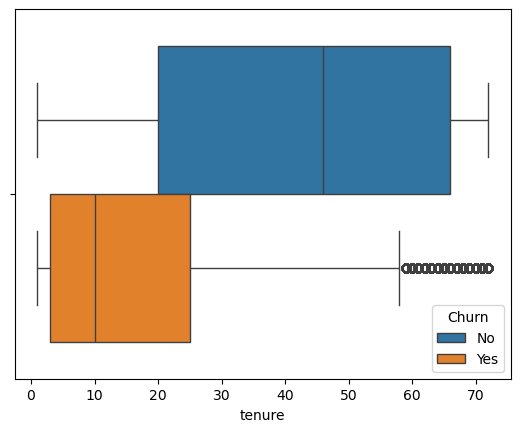

In [8]:
sns.boxplot(data=train, x='tenure', hue='Churn')

<Axes: xlabel='MonthlyCharges'>

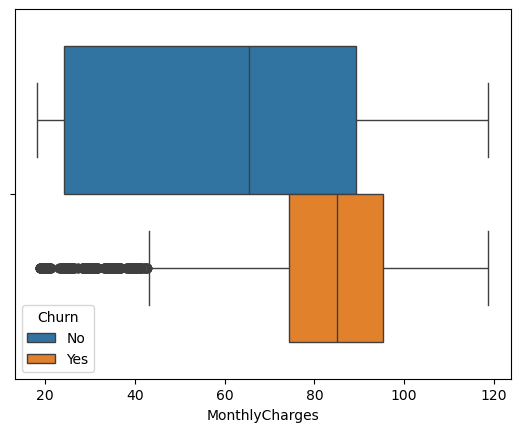

In [9]:
sns.boxplot(data=train, x='MonthlyCharges', hue='Churn')

<Axes: xlabel='TotalCharges'>

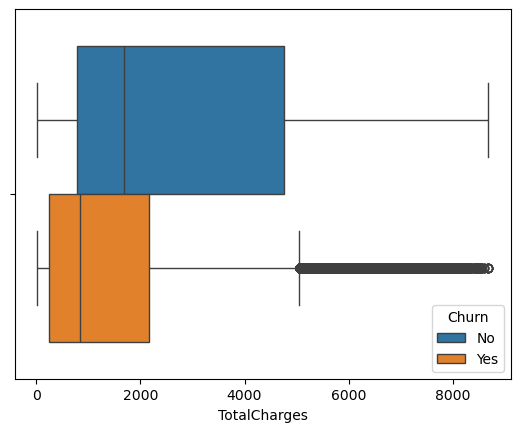

In [10]:
sns.boxplot(data=train, x='TotalCharges', hue='Churn')

<Axes: xlabel='tenure', ylabel='Count'>

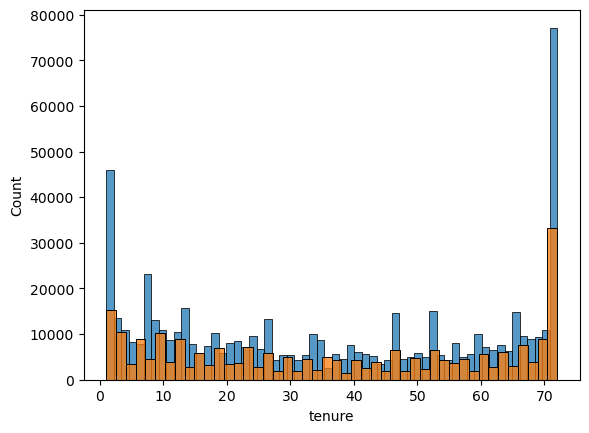

In [14]:
sns.histplot(data=train, x='tenure')
sns.histplot(data=test, x='tenure')

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

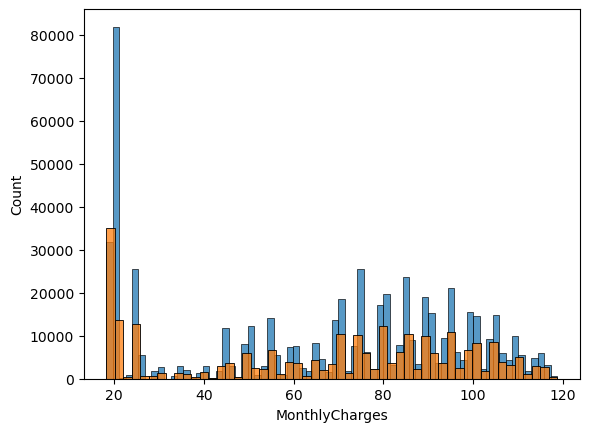

In [15]:
sns.histplot(data=train, x='MonthlyCharges')
sns.histplot(data=test, x='MonthlyCharges')

<Axes: xlabel='TotalCharges', ylabel='Count'>

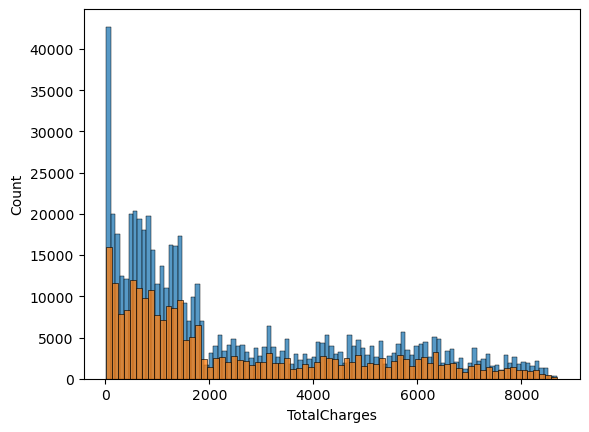

In [16]:
sns.histplot(data=train, x='TotalCharges')
sns.histplot(data=test, x='TotalCharges')

<Axes: >

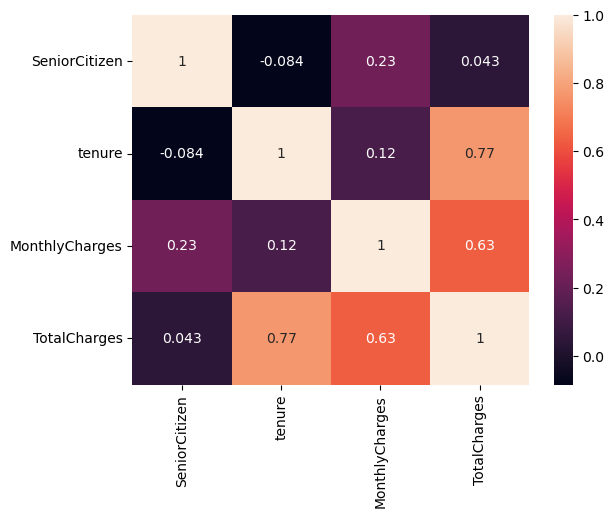

In [22]:
sns.heatmap(train.corr(numeric_only=True), annot=True)

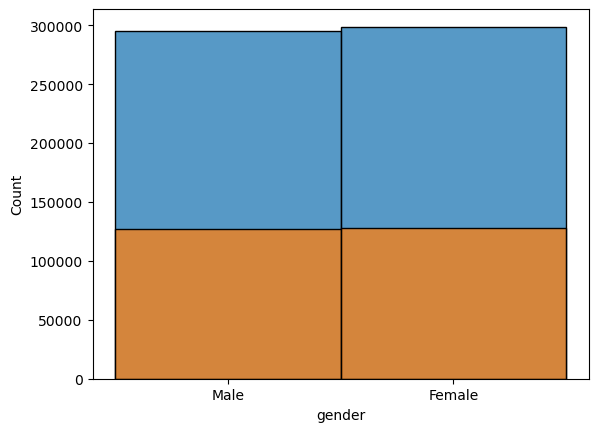

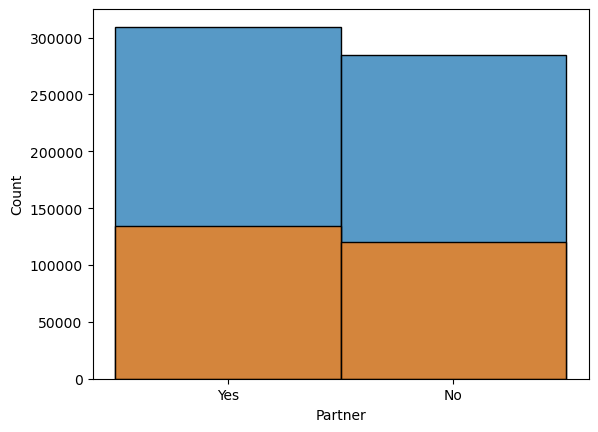

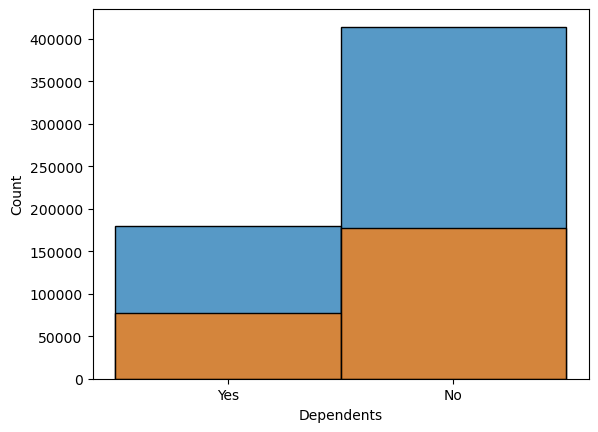

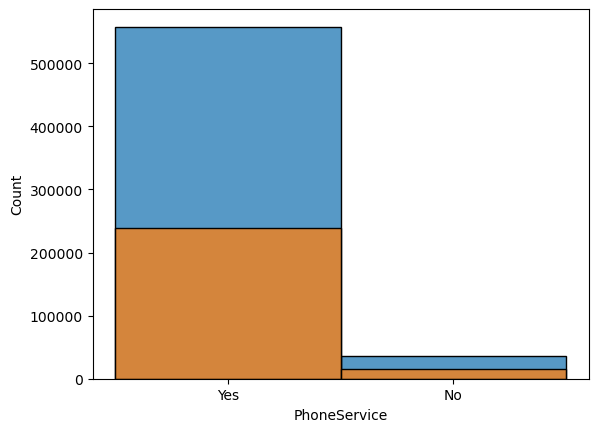

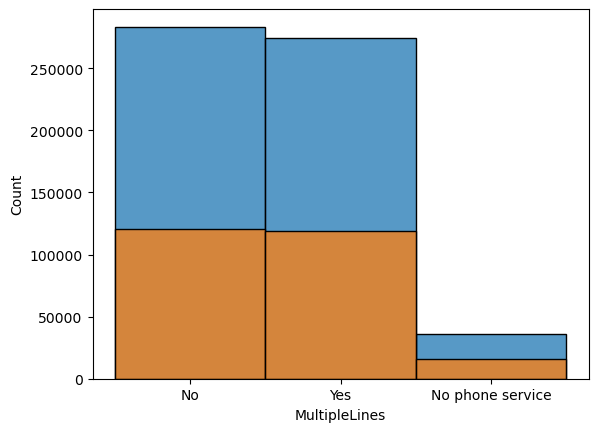

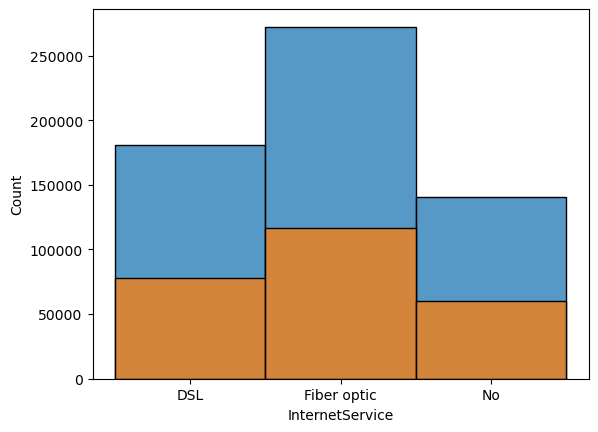

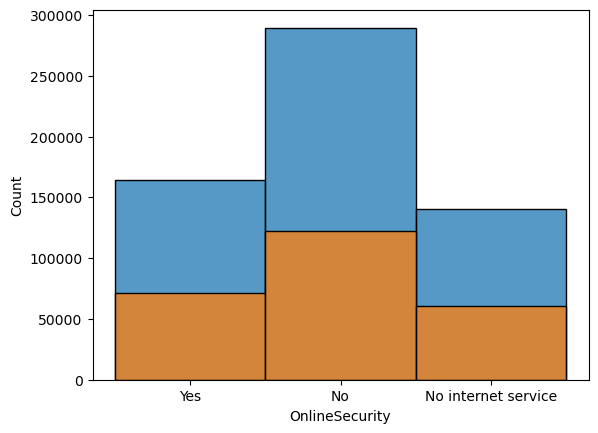

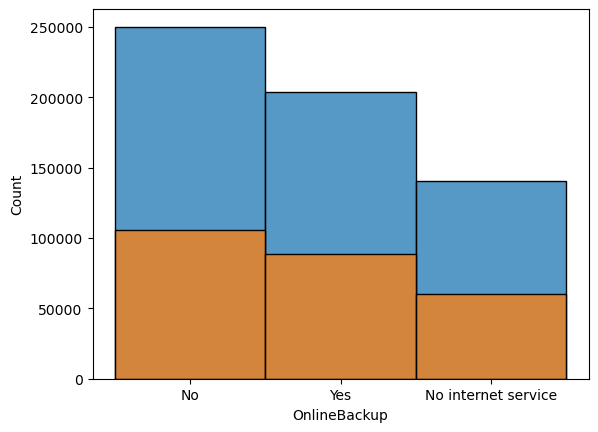

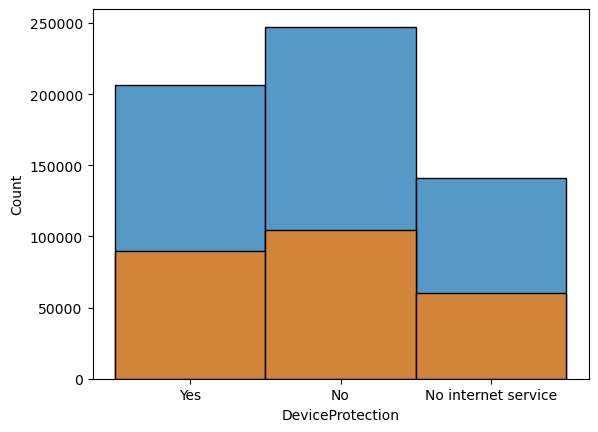

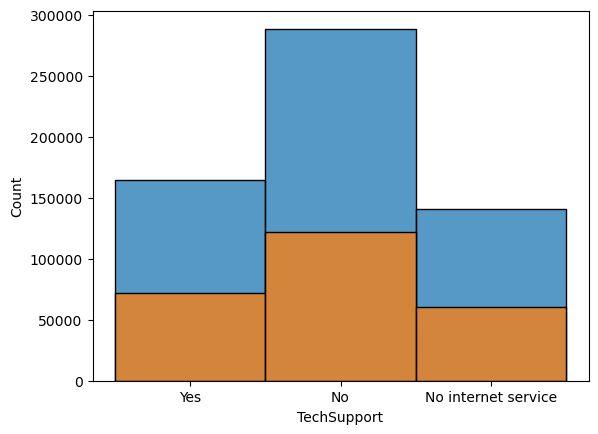

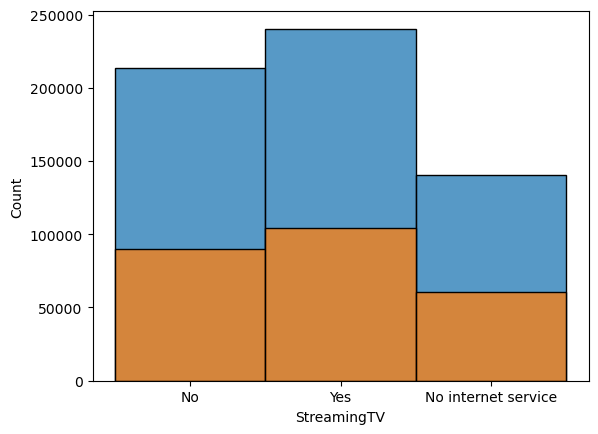

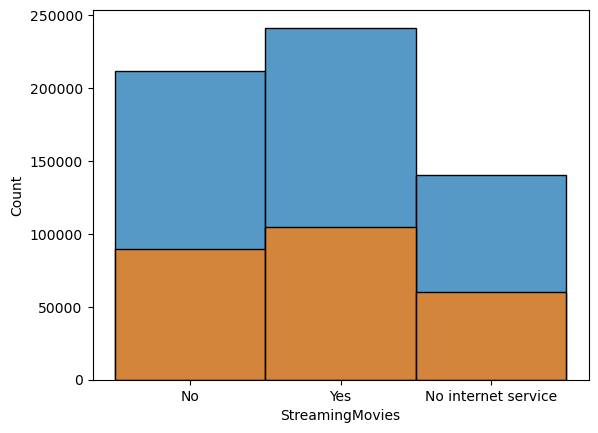

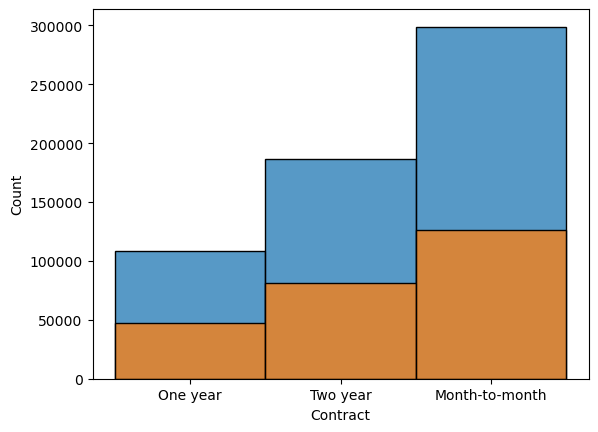

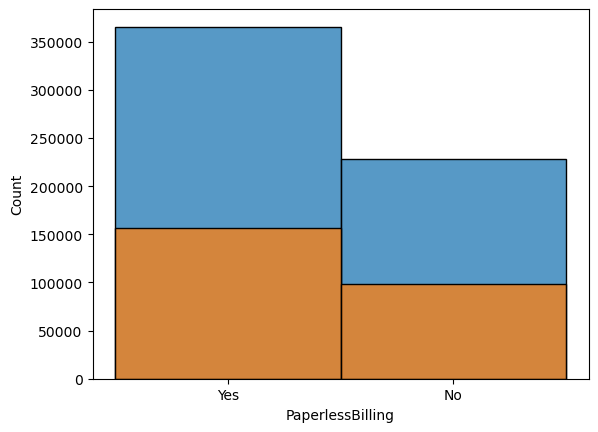

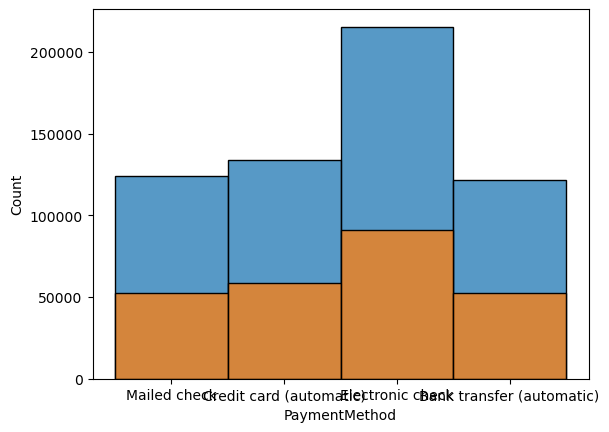

In [37]:
for column in categorical_features:
    sns.histplot(data=train, x=column)
    sns.histplot(data=test, x=column)
    plt.show()

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
     transformers=[
        ('onehot', OneHotEncoder(drop='first', sparse_output=False), categorical_features),
        ('scaler', StandardScaler(), numerical_features)
    ],
    remainder='passthrough'
)

preprocessor.set_output(transform='pandas')

X_encoded = preprocessor.fit_transform(X)
test_encoded = preprocessor.transform(test)

<Axes: >

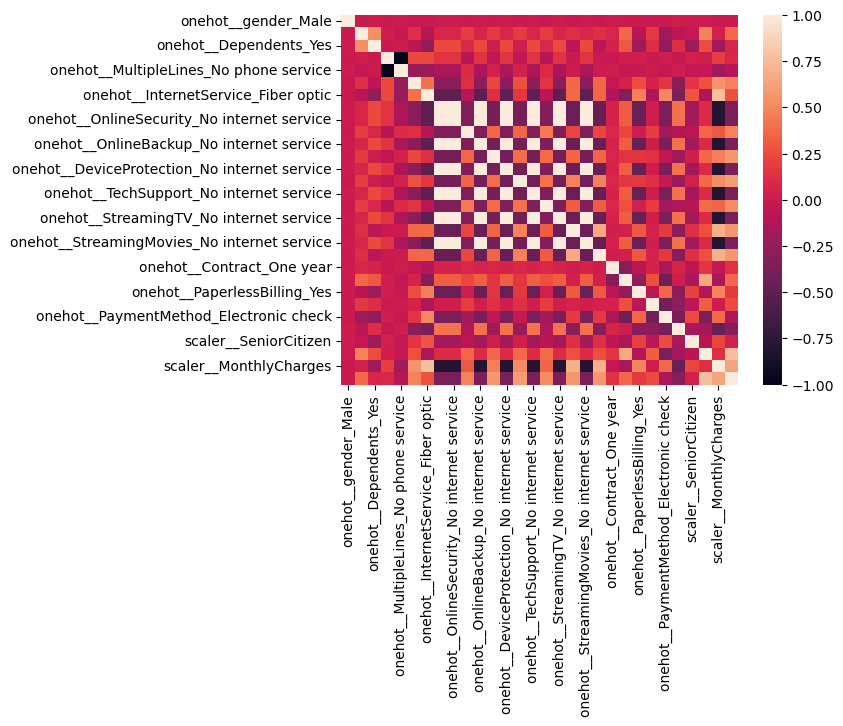

In [24]:
sns.heatmap(X_encoded.corr())